# IT3051 — Fundamentals of Data Mining
# Mini Project: Employee Attrition Prediction

**Stage 3 — Data Understanding & Exploratory Data Analysis**
**Stage 4 — Data Preprocessing & Feature Engineering**

Dataset: HR Attrition Indian Dataset (Kaggle, kmldas) — 5,000 employee records
Target variable: `LeftCompany` (Yes / No) — binary classification

Team FourCast | Group: Y3.S1.WE.DS.02.01 | Module: IT3051

## 0. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Dataset and Inspect Structure

In [2]:
df = pd.read_csv('HR_Attrition_Indian_Dataset.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 5000 rows x 22 columns


,EmployeeID,FullName,Age,Gender,Department,Designation,EducationQualification,MonthlySalary,DateOfJoining,YearsWithCompany,YearsInRole,AppraisalRating,TrainingHours,DoesOvertime,JobSatisfaction,WorkLifeBalance,MaritalStatus,PreviousCompanies,DistanceFromHome,LeavesTaken,City,LeftCompany
0,EMP20230001,Sahil Tailor,48,Other,HR,Accounts Officer,B.Tech,111813,26/05/2020,5,0,3,37,Yes,4,3,Single,0,12.2,4,Mumbai,No
1,EMP20230002,Parinaaz Choudhary,26,Female,IT,Accounts Officer,B.Tech,87425,02/10/2020,5,2,3,39,No,2,2,Divorced,0,36.7,29,Kolkata,No
2,EMP20230003,Anahi Babu,40,Male,IT,Software Engineer,Diploma,86461,01/05/2021,4,4,2,32,No,2,3,Married,1,45.4,0,Bengaluru,Yes
3,EMP20230004,Dhruv Dass,54,Other,HR,Accounts Officer,Diploma,23720,01/04/2023,2,2,1,21,Yes,4,4,Married,0,29.9,27,Kolkata,No
4,EMP20230005,Seher Bal,51,Other,Admin,Sales Associate,B.Tech,39041,19/12/2018,7,1,1,30,No,2,2,Single,0,26.8,6,Delhi,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   EmployeeID              5000 non-null   str    
 1   FullName                5000 non-null   str    
 2   Age                     5000 non-null   int64  
 3   Gender                  5000 non-null   str    
 4   Department              5000 non-null   str    
 5   Designation             5000 non-null   str    
 6   EducationQualification  5000 non-null   str    
 7   MonthlySalary           5000 non-null   int64  
 8   DateOfJoining           5000 non-null   str    
 9   YearsWithCompany        5000 non-null   int64  
 10  YearsInRole             5000 non-null   int64  
 11  AppraisalRating         5000 non-null   int64  
 12  TrainingHours           5000 non-null   int64  
 13  DoesOvertime            5000 non-null   str    
 14  JobSatisfaction         5000 non-null   int64  
 15

In [4]:
# Parse the join date properly (DD/MM/YYYY as used in the source)
df['DateOfJoining'] = pd.to_datetime(df['DateOfJoining'], format='%d/%m/%Y')
print("Joining date range:", df['DateOfJoining'].min().date(), "to", df['DateOfJoining'].max().date())

Joining date range: 2015-06-10 to 2024-06-07


**Variable type summary**

| Type | Columns |
|---|---|
| Identifier (drop) | EmployeeID, FullName |
| Numeric (continuous) | Age, MonthlySalary, DistanceFromHome |
| Numeric (discrete/count) | YearsWithCompany, YearsInRole, TrainingHours, PreviousCompanies, LeavesTaken |
| Ordinal (survey/rating, already 1-5 scale) | AppraisalRating, JobSatisfaction, WorkLifeBalance |
| Nominal categorical | Gender, Department, Designation, EducationQualification, MaritalStatus, City |
| Binary | DoesOvertime |
| Date | DateOfJoining |
| **Target** | **LeftCompany** (Yes/No) |

## 2. Missing Values and Duplicate Records

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_summary[missing_summary['missing_count'] > 0] if missing.sum() > 0 else "No missing values found in any of the 22 columns.")

No missing values found in any of the 22 columns.


In [6]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate EmployeeIDs:", df['EmployeeID'].duplicated().sum())

Fully duplicated rows: 0
Duplicate EmployeeIDs: 0


**Finding:** The dataset is exceptionally clean — 0 missing values across all columns and 0 duplicate records. This is unusual for real-world HR data and, combined with the flat attrition rates seen later across most categorical groups, supports treating this as a synthetically generated (but well-structured) dataset. This will be documented as a limitation, not hidden.

## 3. Data Consistency Checks

In [7]:
# Logical check: an employee cannot be in their current role longer than their total tenure
inconsistent = (df['YearsInRole'] > df['YearsWithCompany']).sum()
print(f"Records where YearsInRole > YearsWithCompany: {inconsistent}")

# Cross-check tenure against the actual joining date
reference_date = df['DateOfJoining'].max()
tenure_from_date = (reference_date - df['DateOfJoining']).dt.days / 365.25
corr_tenure = np.corrcoef(tenure_from_date, df['YearsWithCompany'])[0, 1]
print(f"Correlation between YearsWithCompany and tenure derived from DateOfJoining: {corr_tenure:.3f}")

Records where YearsInRole > YearsWithCompany: 0
Correlation between YearsWithCompany and tenure derived from DateOfJoining: 0.994


**Finding:** No logical inconsistencies. `YearsWithCompany` is almost perfectly explained by `DateOfJoining` (r ≈ 0.99), meaning the two carry redundant information — this is flagged now and will be resolved in the feature selection step to avoid multicollinearity.

## 4. Descriptive Statistics — Numeric Variables

In [8]:
numeric_cols = ['Age', 'MonthlySalary', 'YearsWithCompany', 'YearsInRole', 'AppraisalRating',
                'TrainingHours', 'JobSatisfaction', 'WorkLifeBalance', 'PreviousCompanies',
                'DistanceFromHome', 'LeavesTaken']
df[numeric_cols].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,40.7,11.4,22.0,31.0,41.0,51.0,60.0
MonthlySalary,5000.0,68200.9,30290.7,15031.0,42086.0,68358.5,94889.5,119878.0
YearsWithCompany,5000.0,5.6,2.6,1.0,3.0,6.0,8.0,10.0
YearsInRole,5000.0,2.8,2.4,0.0,1.0,2.0,4.0,10.0
AppraisalRating,5000.0,3.0,1.4,1.0,2.0,3.0,4.0,5.0
TrainingHours,5000.0,30.1,17.6,0.0,15.0,30.0,45.0,60.0
JobSatisfaction,5000.0,3.0,1.4,1.0,2.0,3.0,4.0,5.0
WorkLifeBalance,5000.0,2.5,1.1,1.0,2.0,2.5,4.0,4.0
PreviousCompanies,5000.0,2.5,1.7,0.0,1.0,3.0,4.0,5.0
DistanceFromHome,5000.0,25.5,14.2,1.0,13.2,25.5,37.7,50.0


## 5. Target Variable — Class Distribution

LeftCompany
No     3145
Yes    1855
Name: count, dtype: int64
LeftCompany
No     62.9
Yes    37.1
Name: proportion, dtype: float64


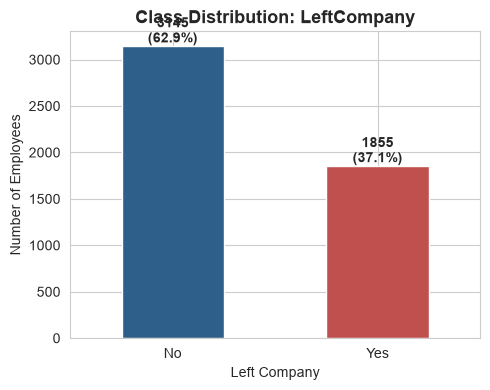

In [9]:
target_counts = df['LeftCompany'].value_counts()
target_pct = df['LeftCompany'].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct.round(1))

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#2E5F8A', '#C0504D']
target_counts.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Class Distribution: LeftCompany', fontsize=13, fontweight='bold')
ax.set_xlabel('Left Company')
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(target_counts.index, rotation=0)
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 40, f"{v}\n({target_pct.values[i]:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=120)
plt.show()

**Finding:** The target is moderately imbalanced — **62.9% No / 37.1% Yes** (ratio ≈ 1.7:1). This is realistic for Indian attrition rates and is imbalanced enough that plain accuracy will be a misleading metric later — precision, recall, F1, and ROC-AUC will be used instead, and class-weighting/resampling will be considered at the modelling stage (Stage 6-7), not here.

## 6. Univariate Distributions — Numeric Features

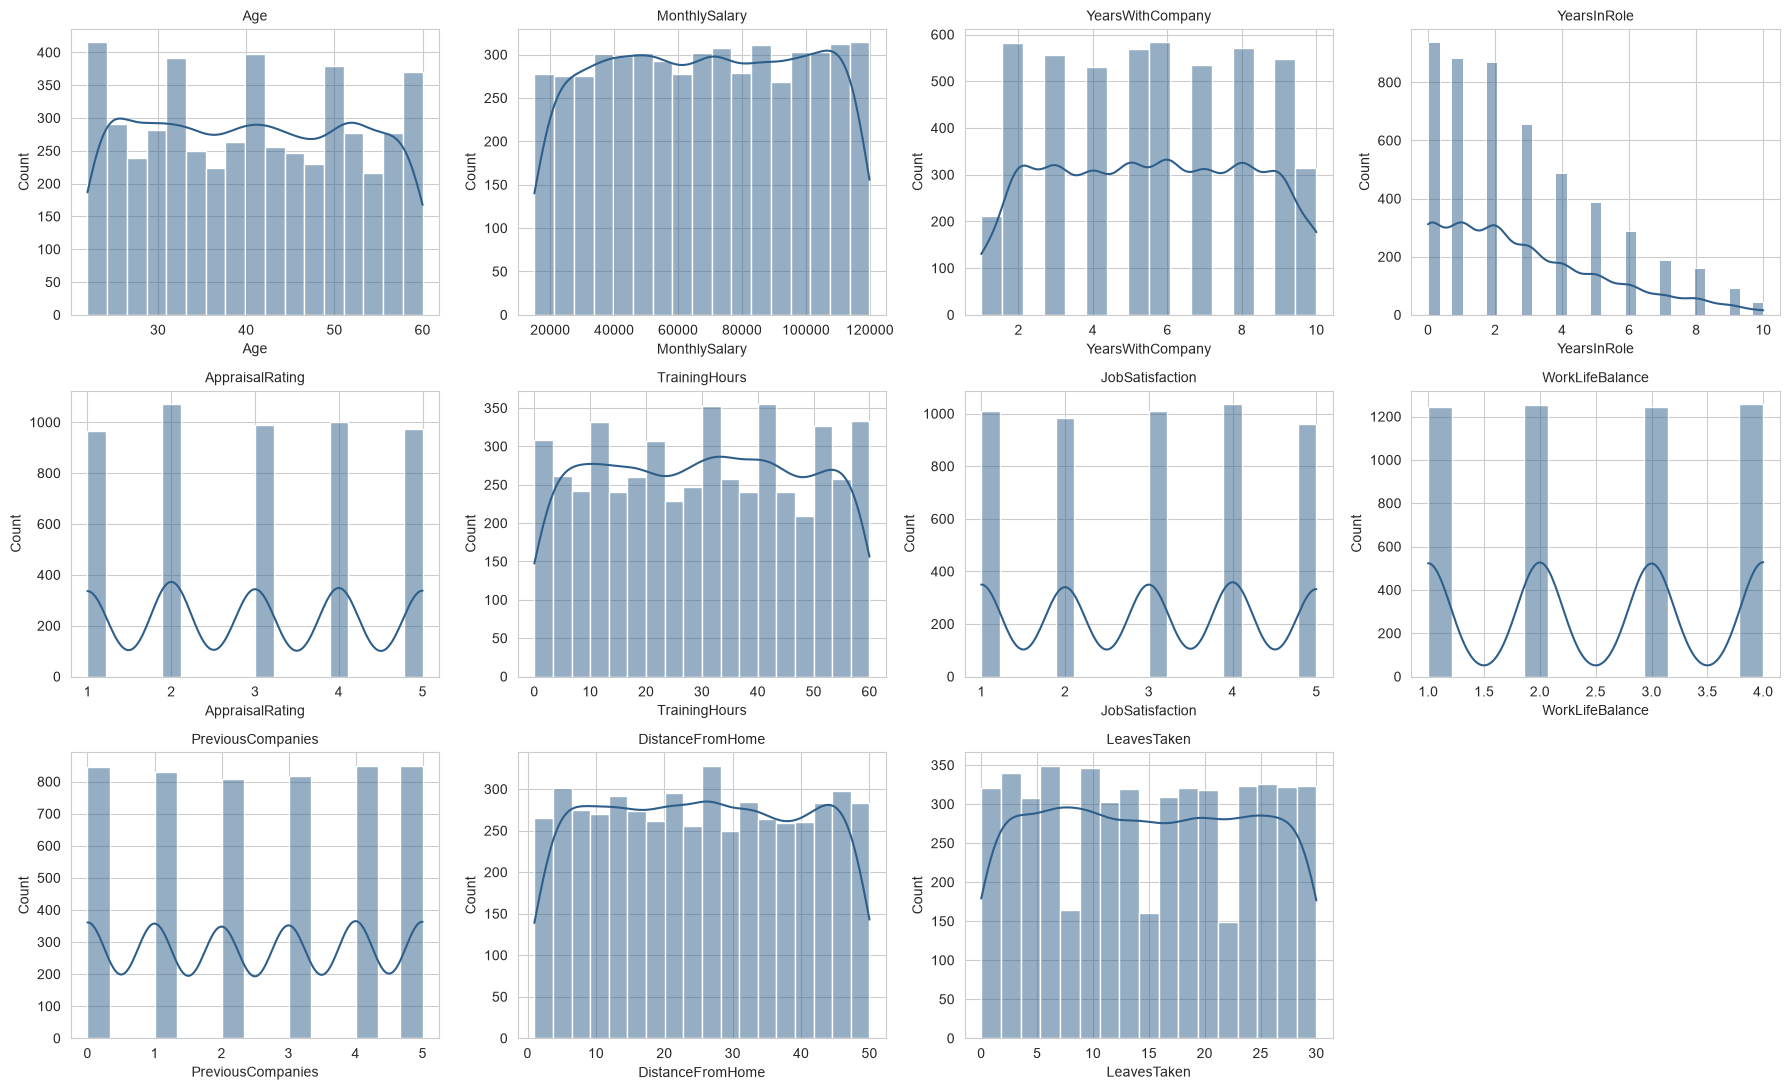

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#2E5F8A')
    axes[i].set_title(col, fontsize=10)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('fig_numeric_distributions.png', dpi=120)
plt.show()

**Finding:** All numeric variables are approximately uniformly distributed across their stated ranges (e.g., Age spans 22-60 fairly evenly, Salary spans ₹15k-₹120k evenly). This is another indicator of synthetic generation — real HR data is rarely this evenly spread — but it also means there is no single dominant sub-population skewing the analysis.

## 7. Outlier Investigation

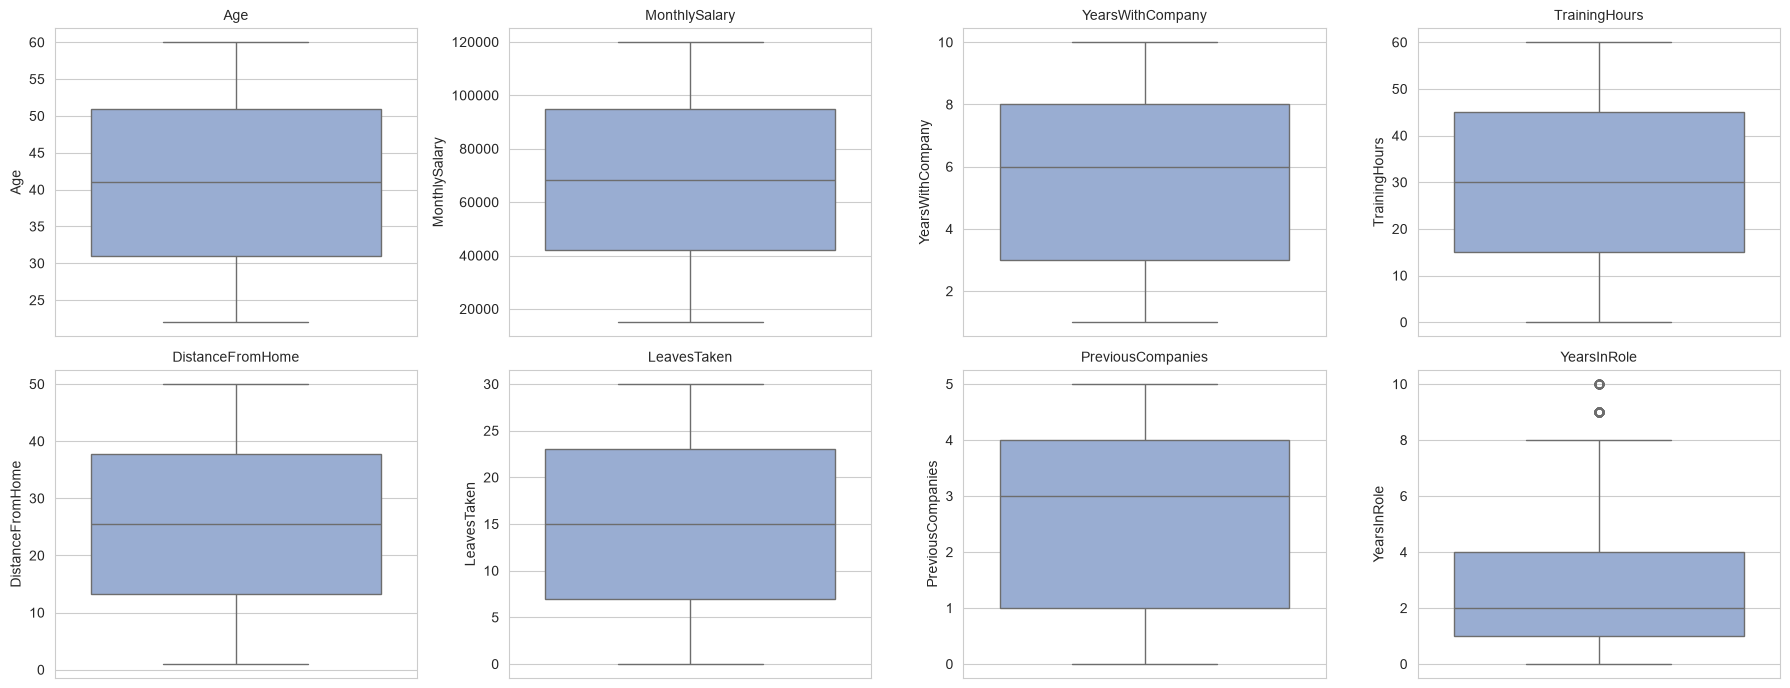

IQR-based outlier counts:
  Age                 : 0 potential outliers (valid range 1.0 to 81.0)
  MonthlySalary       : 0 potential outliers (valid range -37119.2 to 174094.8)
  YearsWithCompany    : 0 potential outliers (valid range -4.5 to 15.5)
  TrainingHours       : 0 potential outliers (valid range -30.0 to 90.0)
  DistanceFromHome    : 0 potential outliers (valid range -23.6 to 74.5)
  LeavesTaken         : 0 potential outliers (valid range -17.0 to 47.0)
  PreviousCompanies   : 0 potential outliers (valid range -3.5 to 8.5)
  YearsInRole         : 137 potential outliers (valid range -3.5 to 8.5)


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
outlier_check_cols = ['Age', 'MonthlySalary', 'YearsWithCompany', 'TrainingHours',
                      'DistanceFromHome', 'LeavesTaken', 'PreviousCompanies', 'YearsInRole']
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#8FAADC')
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.savefig('fig_outlier_boxplots.png', dpi=120)
plt.show()

# IQR-based outlier count per column
print("IQR-based outlier counts:")
for col in outlier_check_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col:20s}: {n_out} potential outliers (valid range {lower:.1f} to {upper:.1f})")

**Finding and decision:** No boxplot shows values outside a realistic HR range, and the IQR method flags none of the numeric columns. **No outlier removal is applied.** A high salary or a long commute here reflects a genuine senior employee or a genuine long-distance commuter, not a data-entry error — removing such rows would discard real information rather than clean the data.

## 8. Categorical Variable Distributions

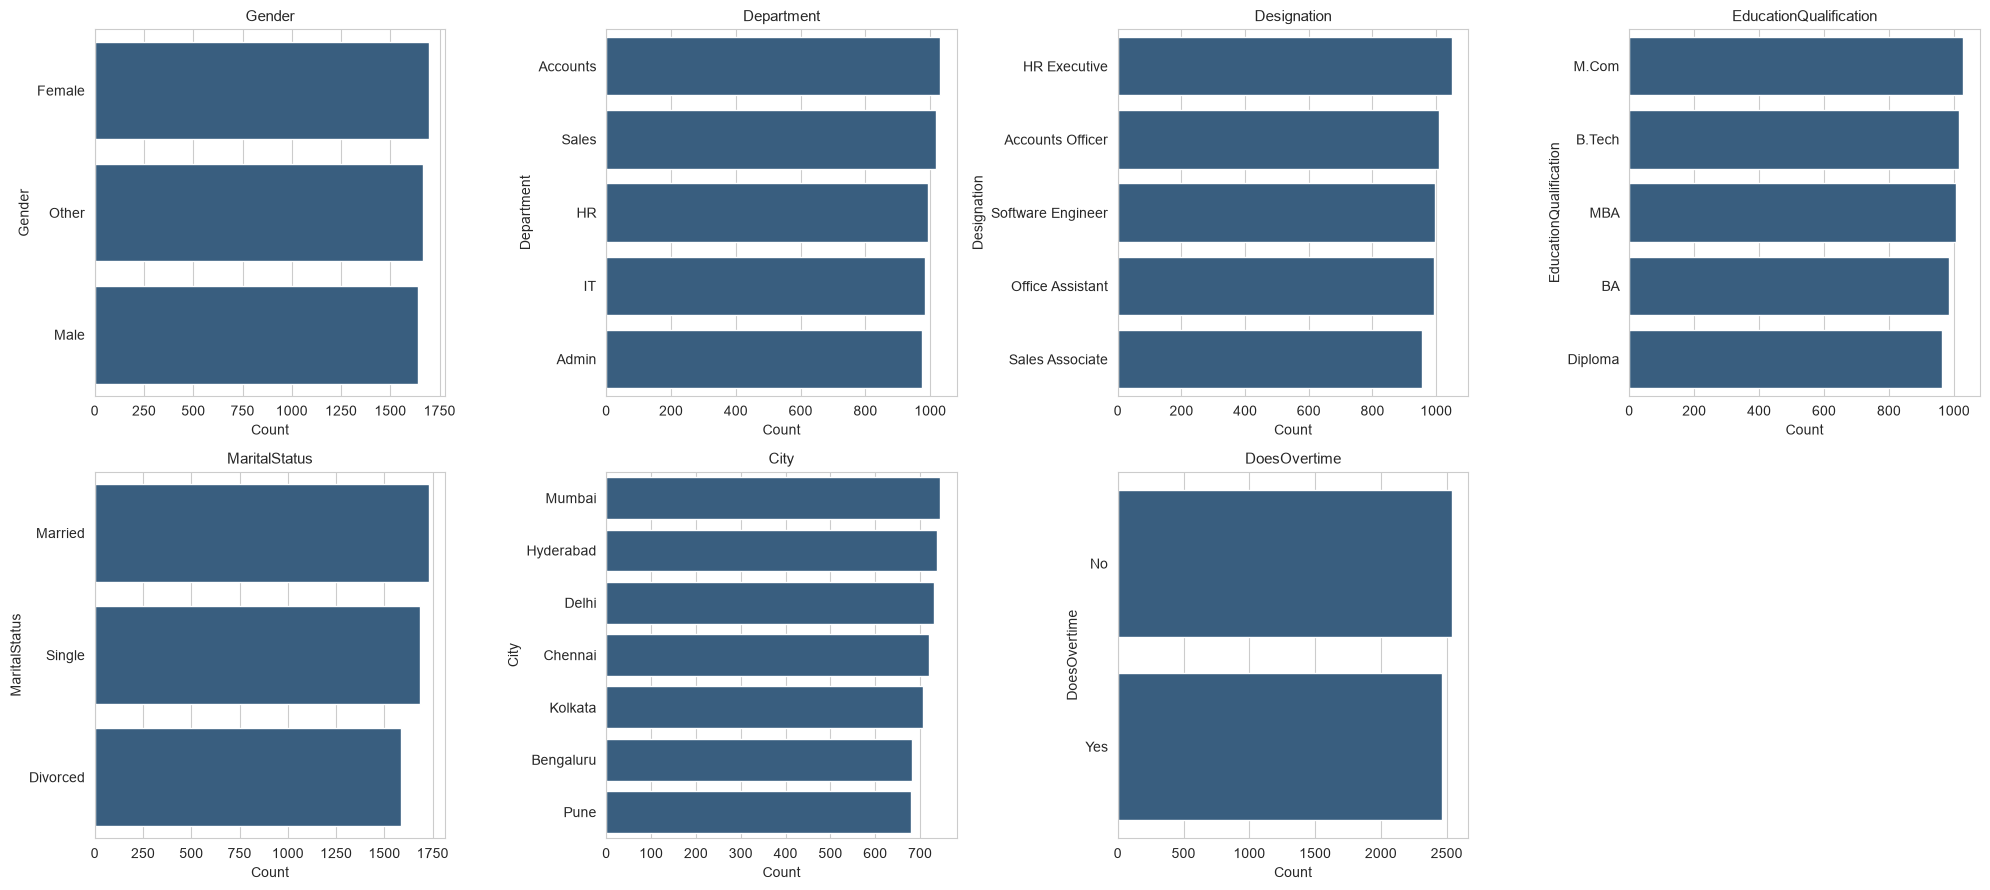


Gender:
Gender
Female    1695
Other     1664
Male      1641
Name: count, dtype: int64

Department:
Department
Accounts    1031
Sales       1019
HR           992
IT           983
Admin        975
Name: count, dtype: int64

Designation:
Designation
HR Executive         1049
Accounts Officer     1008
Software Engineer     995
Office Assistant      993
Sales Associate       955
Name: count, dtype: int64

EducationQualification:
EducationQualification
M.Com      1029
B.Tech     1017
MBA        1007
BA          985
Diploma     962
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     1730
Single      1685
Divorced    1585
Name: count, dtype: int64

City:
City
Mumbai       745
Hyderabad    737
Delhi        732
Chennai      719
Kolkata      707
Bengaluru    681
Pune         679
Name: count, dtype: int64

DoesOvertime:
DoesOvertime
No     2539
Yes    2461
Name: count, dtype: int64


In [12]:
cat_cols = ['Gender', 'Department', 'Designation', 'EducationQualification', 'MaritalStatus', 'City', 'DoesOvertime']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], color='#2E5F8A')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Count')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig('fig_categorical_distributions.png', dpi=120)
plt.show()

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

**Finding:** Categories are fairly evenly represented across Department (5 categories), Designation (5), Education (5) and City (7), again consistent with synthetic, balanced generation. `Gender` has a small 'Other' category which will need monitoring for unstable estimates during modelling and fairness checks.

## 9. Bivariate Analysis — Categorical Features vs Attrition

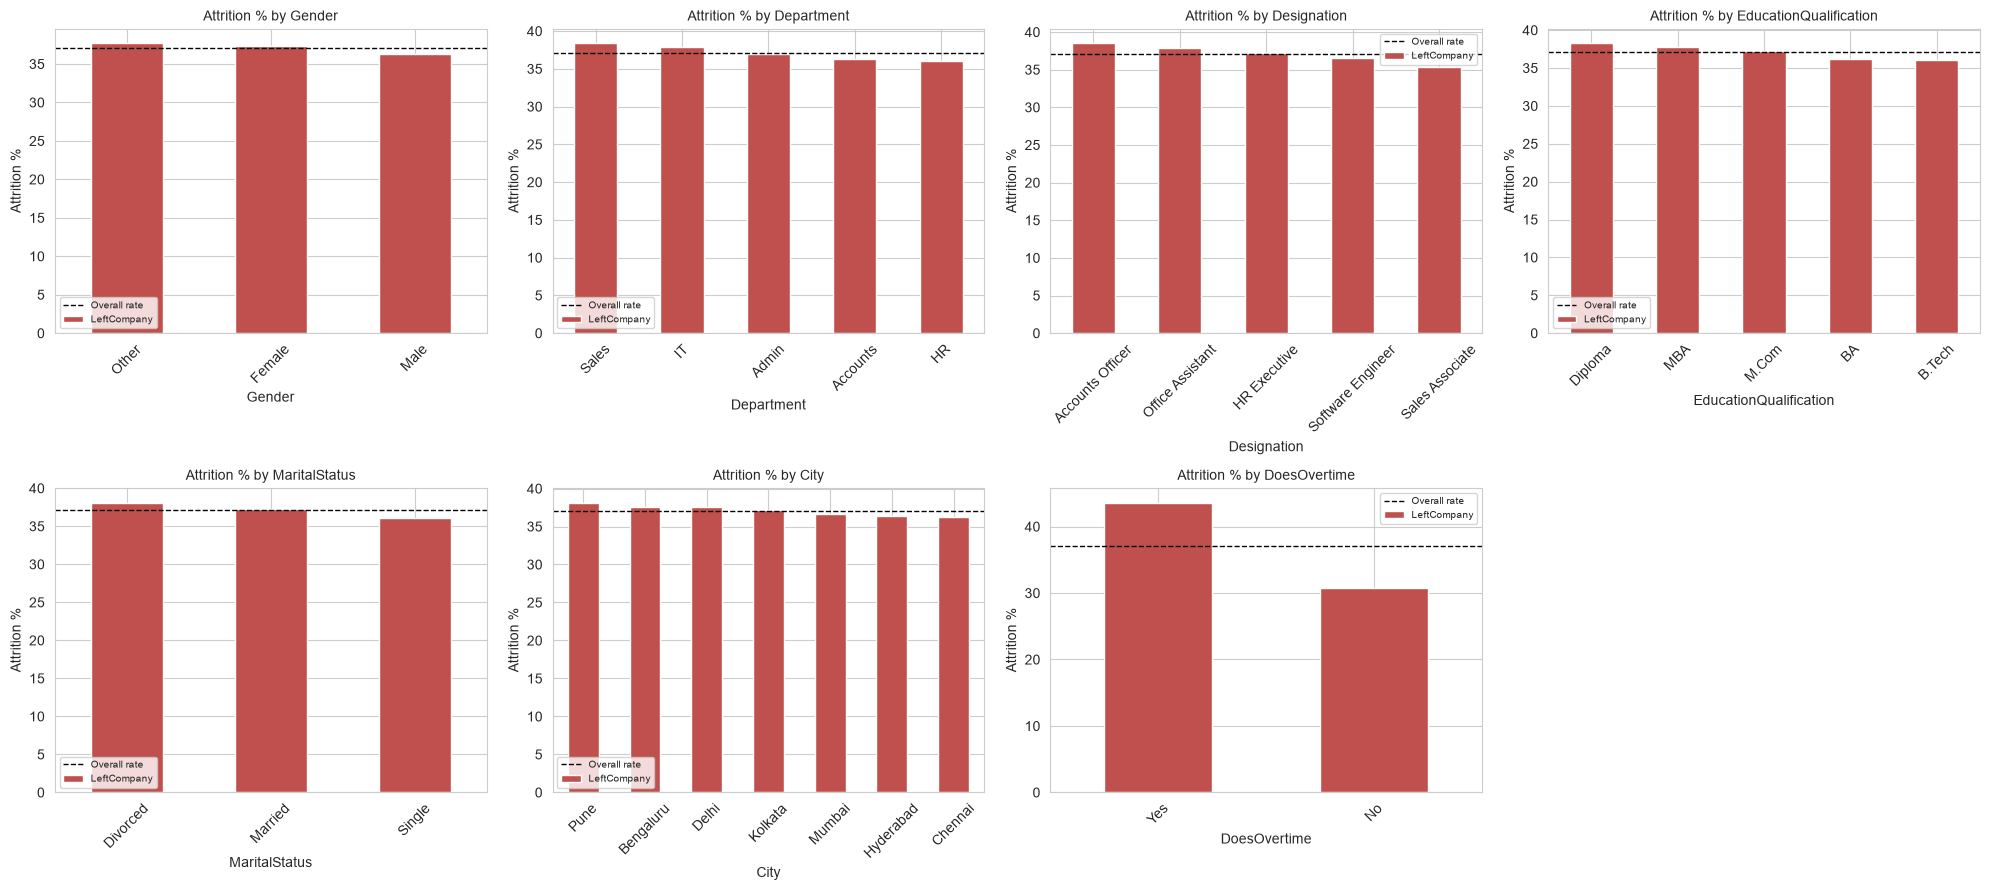


Attrition % by Gender:
Gender
Other     37.7
Female    37.3
Male      36.3
Name: LeftCompany, dtype: float64

Attrition % by Department:
Department
Sales       38.4
IT          37.9
Admin       36.9
Accounts    36.3
HR          36.0
Name: LeftCompany, dtype: float64

Attrition % by Designation:
Designation
Accounts Officer     38.5
Office Assistant     37.9
HR Executive         37.3
Software Engineer    36.5
Sales Associate      35.3
Name: LeftCompany, dtype: float64

Attrition % by EducationQualification:
EducationQualification
Diploma    38.3
MBA        37.7
M.Com      37.2
BA         36.2
B.Tech     36.1
Name: LeftCompany, dtype: float64

Attrition % by MaritalStatus:
MaritalStatus
Divorced    38.1
Married     37.2
Single      36.0
Name: LeftCompany, dtype: float64

Attrition % by City:
City
Pune         38.1
Bengaluru    37.6
Delhi        37.6
Kolkata      37.2
Mumbai       36.6
Hyderabad    36.4
Chennai      36.3
Name: LeftCompany, dtype: float64

Attrition % by DoesOvertime:
Doe

In [13]:
def attrition_rate_by(col):
    return (df.groupby(col, observed=True)['LeftCompany']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .sort_values(ascending=False))

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rates = attrition_rate_by(col)
    rates.plot(kind='bar', ax=axes[i], color='#C0504D')
    axes[i].axhline(df['LeftCompany'].eq('Yes').mean()*100, color='black', linestyle='--', linewidth=1, label='Overall rate')
    axes[i].set_title(f'Attrition % by {col}', fontsize=10)
    axes[i].set_ylabel('Attrition %')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=7)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig('fig_attrition_by_categorical.png', dpi=120)
plt.show()

for col in cat_cols:
    print(f"\nAttrition % by {col}:")
    print(attrition_rate_by(col).round(1))

**Finding:** `DoesOvertime` is the standout categorical driver — employees working overtime leave at **43.6%** vs **30.8%** for those who don't, a 13-point gap. Department, Designation, Education, Marital Status, City and Gender all show attrition rates within a narrow 35-38% band around the 37.1% baseline — essentially no discriminating signal. This matters directly for feature selection in Stage 4/7: several categorical columns may contribute little beyond noise.

## 10. Bivariate Analysis — Numeric Features vs Attrition

C:\Users\Haran Akash\AppData\Local\Temp\ipykernel_30556\889016994.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LeftCompany', y=col, data=df, ax=axes[i], palette=['#2E5F8A', '#C0504D'])
C:\Users\Haran Akash\AppData\Local\Temp\ipykernel_30556\889016994.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LeftCompany', y=col, data=df, ax=axes[i], palette=['#2E5F8A', '#C0504D'])
C:\Users\Haran Akash\AppData\Local\Temp\ipykernel_30556\889016994.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LeftCompany', y=col, data=df, ax=axe

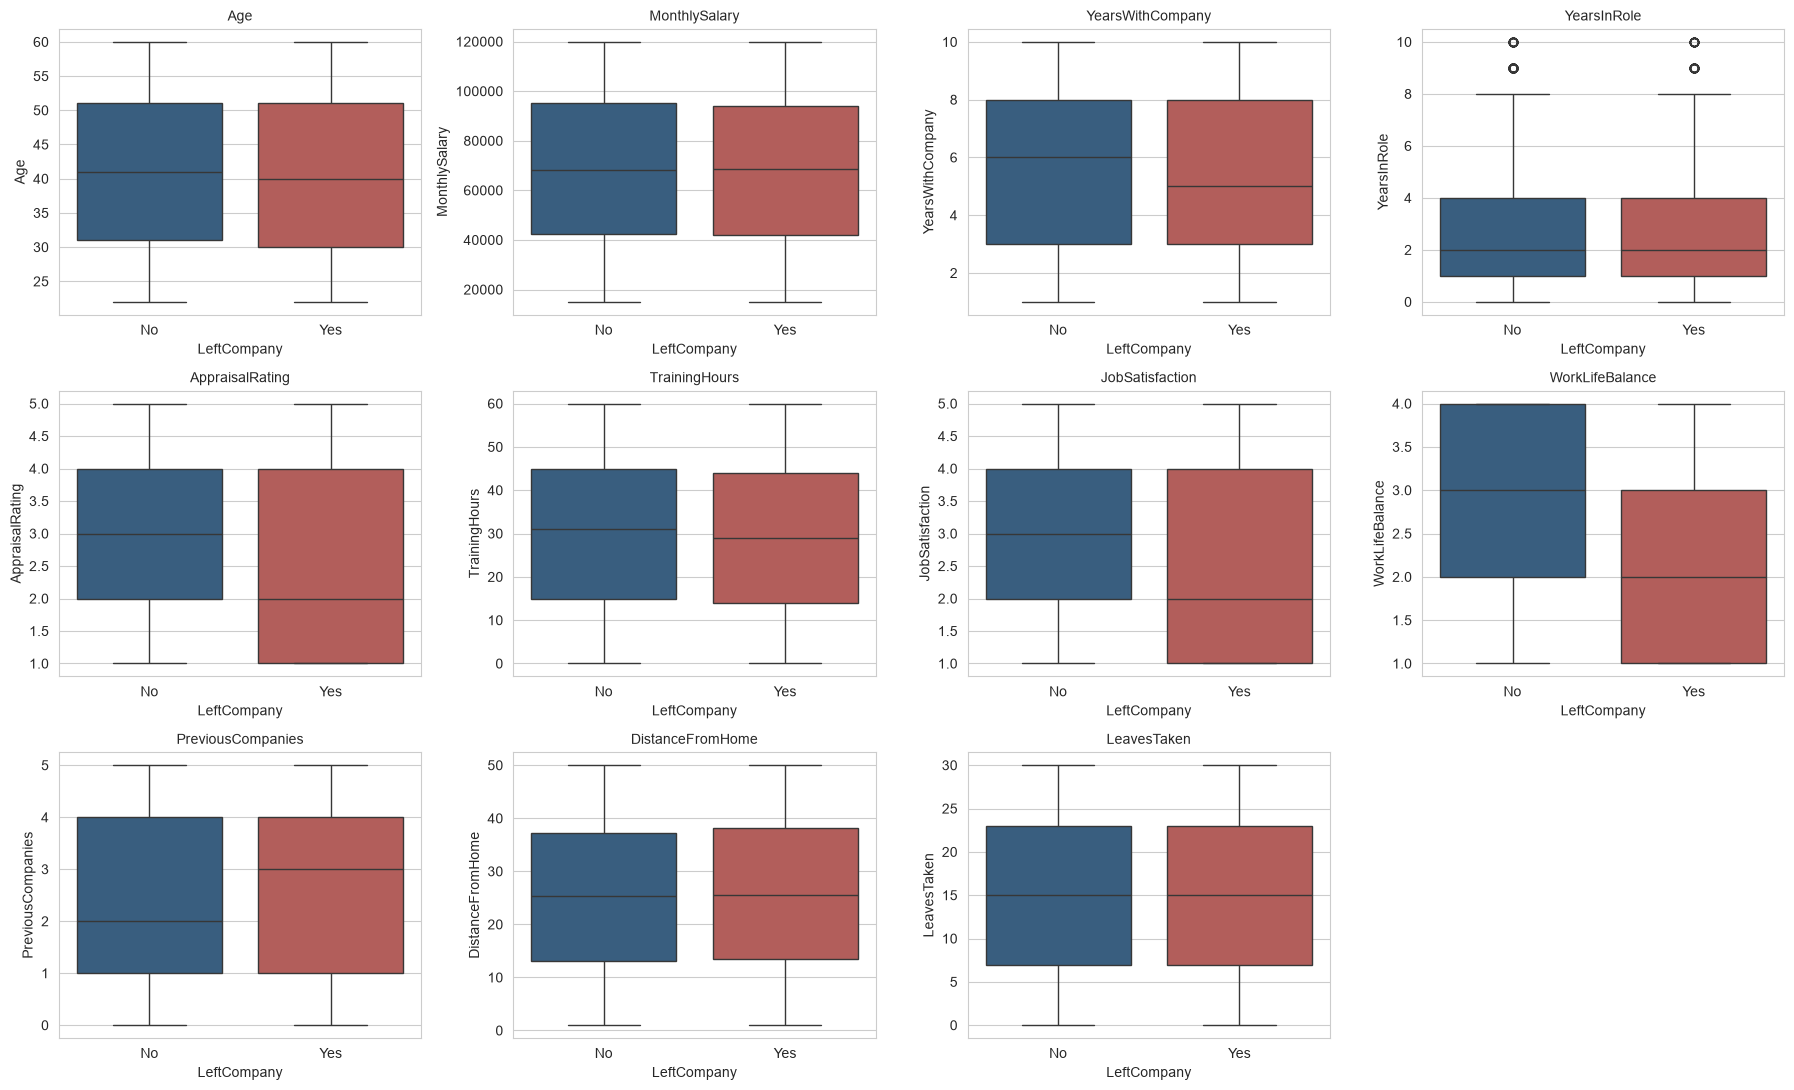

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='LeftCompany', y=col, data=df, ax=axes[i], palette=['#2E5F8A', '#C0504D'])
    axes[i].set_title(col, fontsize=10)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('fig_numeric_vs_target.png', dpi=120)
plt.show()

Correlation with attrition (LeftCompany = Yes), sorted by strength:
JobSatisfaction     -0.208
AppraisalRating     -0.183
WorkLifeBalance     -0.167
PreviousCompanies    0.046
TrainingHours       -0.022
YearsWithCompany    -0.020
Age                 -0.008
YearsInRole         -0.007
DistanceFromHome     0.007
MonthlySalary       -0.007
LeavesTaken          0.000
dtype: float64


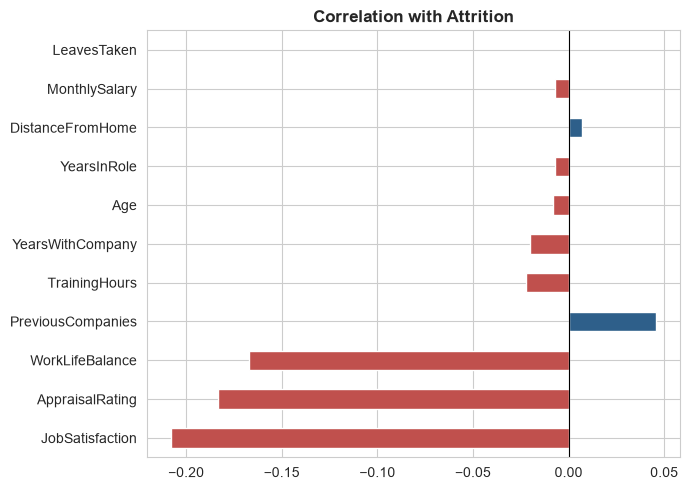

In [15]:
# Point-biserial correlation (numeric feature vs binary target)
y_numeric = (df['LeftCompany'] == 'Yes').astype(int)
correlations = df[numeric_cols].corrwith(y_numeric).sort_values(key=abs, ascending=False)
print("Correlation with attrition (LeftCompany = Yes), sorted by strength:")
print(correlations.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
correlations.plot(kind='barh', color=['#C0504D' if v < 0 else '#2E5F8A' for v in correlations], ax=ax)
ax.set_title('Correlation with Attrition', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('fig_correlation_with_target.png', dpi=120)
plt.show()

**Finding — the most important EDA result for this project:** Predictive signal is concentrated in just three numeric variables:
- `JobSatisfaction` (r ≈ -0.21) — lower satisfaction, higher attrition
- `AppraisalRating` (r ≈ -0.18) — lower ratings, higher attrition
- `WorkLifeBalance` (r ≈ -0.17) — poorer balance, higher attrition

`MonthlySalary`, `Age`, `YearsWithCompany`, `YearsInRole`, `DistanceFromHome`, `LeavesTaken`, `TrainingHours` and `PreviousCompanies` all show negligible correlation (|r| < 0.05). Combined with `DoesOvertime` from the categorical analysis, this gives four meaningful drivers out of eighteen candidate features. This directly informs feature selection in Stage 7 and sets a realistic expectation ceiling of roughly 0.75-0.80 ROC-AUC for later models — it will not exceed that ceiling because the noise variables genuinely carry little information, not because of a modelling failure.

## 11. Correlation Heatmap and Multicollinearity Check

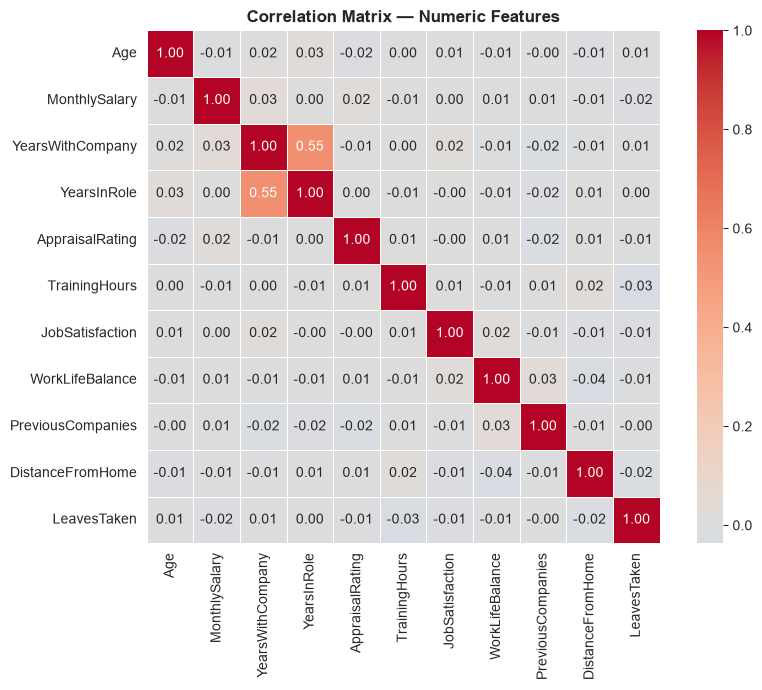

In [16]:
corr_matrix = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=120)
plt.show()

**Finding:** No pair of the *original* numeric columns is strongly correlated (all |r| < 0.05 among themselves) — no multicollinearity issue within the raw features. The one redundancy in the dataset is `YearsWithCompany` vs. the tenure that can be derived from `DateOfJoining` (r ≈ 0.99, shown in Section 3), which will be resolved during feature engineering below by keeping only one of the two.

## 12. Class Imbalance — Formal Assessment

Already quantified in Section 5 (62.9% / 37.1%, ratio ≈ 1.7:1). This is classified as **moderate imbalance** — not severe enough to require aggressive resampling (SMOTE) as a hard requirement, but enough that:
- Accuracy alone would be misleading (a model predicting "No" for everyone scores 62.9% while learning nothing).
- Stratified sampling is required for the train/test split and cross-validation folds (applied in Section 16).
- `class_weight='balanced'` and/or SMOTE will be evaluated and compared during Stage 6-7 model development.

## 13. Data Leakage Risk Assessment

Reviewed explicitly, as required by Stage 3:

| Potential leakage source | Assessment | Action |
|---|---|---|
| `EmployeeID`, `FullName` | Direct identifiers, no predictive meaning, risk of the model memorising individuals | Dropped before modelling |
| `DateOfJoining` | Raw date has no meaning to a model and no future information exists beyond it in this dataset | Converted to derived features (tenure, joining year/month) instead of used raw |
| `YearsWithCompany` vs. date-derived tenure | Near-perfect correlation (r ≈ 0.99) — not leakage, but redundancy that inflates apparent importance of one signal | Keep one, drop the other (Section 14) |
| `JobSatisfaction`, `WorkLifeBalance` | Self-reported survey scores — plausible they could be collected at/near exit for leavers, which would leak the outcome into the feature | No exit-interview timestamp exists in this dataset to confirm this, so retained, but flagged as a documented limitation; a model variant excluding them will be compared in Stage 7 |
| All scaling / encoding statistics | Fitting on the full dataset before splitting would leak test-set distribution into training | All transformations fitted on the training split only, via a pipeline (Section 17) |

**Conclusion:** No direct leakage identified. One redundancy (tenure duplication) will be resolved; one soft risk (engagement scores) is documented and will be stress-tested later rather than removed now.